In [2]:
import pypowsybl as pp
import pypowsybl.loadflow as lf



network = pp.network.load('Svedala_CGMES3.0_CIM17.zip', post_processors=['replaceTieLinesByLines'])
lf.run_ac(network)



[ComponentResult(connected_component_num=0, synchronous_component_num=0, status=CONVERGED, status_text=Converged, iteration_count=10, reference_bus_id='eaa25262-839d-4abf-ad2c-62e2e252bfee_0', slack_bus_results=[SlackBusResult(id='eaa25262-839d-4abf-ad2c-62e2e252bfee_0', active_power_mismatch=0.16358454744439532)], distributed_active_power=-67.01725998312578)]

In [3]:
buses = network.get_buses()
print(buses.loc['eaa25262-839d-4abf-ad2c-62e2e252bfee_0'])

name                                          NORRÅS_4_FT42_0
v_mag                                              391.330339
v_angle                                                   0.0
connected_component                                         0
synchronous_component                                       0
voltage_level_id         eaa25262-839d-4abf-ad2c-62e2e252bfee
Name: eaa25262-839d-4abf-ad2c-62e2e252bfee_0, dtype: object


Result

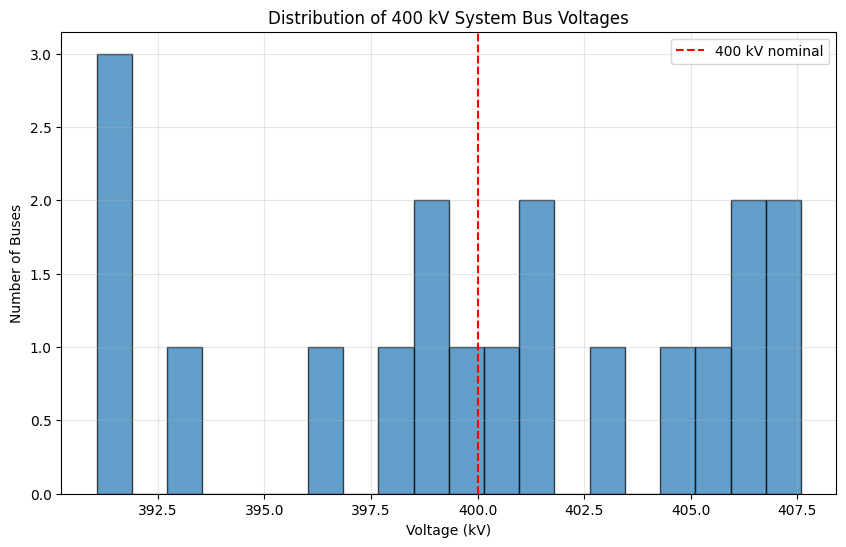

In [5]:
import matplotlib.pyplot as plt

# Filter 400 kV range buses
buses_400kv = buses[(buses['v_mag'] >= 380) & (buses['v_mag'] <= 420)]

if not buses_400kv.empty:
    plt.figure(figsize=(10, 6))
    plt.hist(buses_400kv['v_mag'], bins=20, edgecolor='black', alpha=0.7)
    plt.axvline(400, color='red', linestyle='--', label='400 kV nominal')
    plt.xlabel('Voltage (kV)')
    plt.ylabel('Number of Buses')
    plt.title('Distribution of 400 kV System Bus Voltages')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [17]:
network.save('network.xml', format='CGMES')